In [18]:
import pandas as pd

# Load the clip labels created from Process_boxes_to_classifier_labels.ipynb
clip_labels = pd.read_csv('/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/birds_embeddings_birdnet_padded_3s.csv')
# , index_col=[0,1,2]
# take only first 4 columns
clip_labels = clip_labels.iloc[:, :4]

# make calltype A and M the same = A
clip_labels['calltype'] = clip_labels['calltype'].replace('M', 'A')
# make calltype N and chits the same = Chits
clip_labels['calltype'] = clip_labels['calltype'].replace('N', 'Chits')
# make calltype L and C the same = C
clip_labels['calltype'] = clip_labels['calltype'].replace('L', 'C')

# sort columns like file, start_time, end_time, call_type
clip_labels = clip_labels[['file', 'start_time', 'end_time', 'calltype']]
# make call_type one hot encoding (true or false)
clip_labels = pd.get_dummies(clip_labels, columns=['calltype'])
clip_labels


,file,start_time,end_time,calltype_A,calltype_B,calltype_C,calltype_Check,calltype_Cheer,calltype_Chits,calltype_D,calltype_E,calltype_F,calltype_G,calltype_Growl,calltype_H,calltype_I,calltype_J,calltype_K,calltype_O
0,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
1,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
2,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
3,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
4,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6042,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
6043,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
6044,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
6045,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False


In [19]:
classes = clip_labels.columns[3:].tolist()
classes

['calltype_A',
 'calltype_B',
 'calltype_C',
 'calltype_Check',
 'calltype_Cheer',
 'calltype_Chits',
 'calltype_D',
 'calltype_E',
 'calltype_F',
 'calltype_G',
 'calltype_Growl',
 'calltype_H',
 'calltype_I',
 'calltype_J',
 'calltype_K',
 'calltype_O']

In [20]:
import os
import pandas as pd

# Path to YOLO dataset split files
split_dir = '/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/YOLO/dataset_split/'

# Read the split files and extract unique trial identifiers
def extract_trial_ids(txt_file):
    """Extract unique trial identifiers from YOLO split file"""
    with open(txt_file, 'r') as f:
        paths = [line.strip() for line in f]
    
    # Extract trial IDs from image filenames
    # Format: .../AZ02_Trial_1_trim_spec_00-05.png -> AZ02_Trial_1_trim
    trial_ids = set()
    for path in paths:
        filename = os.path.basename(path)
        # Remove _spec_XX-XX.png to get trial ID
        trial_id = filename.rsplit('_spec_', 1)[0]
        trial_ids.add(trial_id)
    
    return trial_ids

# Extract trial IDs for each split
test_trials = extract_trial_ids(os.path.join(split_dir, 'test.txt'))
val_trials = extract_trial_ids(os.path.join(split_dir, 'validate.txt'))
train_trials = extract_trial_ids(os.path.join(split_dir, 'train.txt'))

print(f"Test trials: {sorted(test_trials)}")
print(f"Validation trials: {sorted(val_trials)}")
print(f"Train trials ({len(train_trials)} total): {sorted(list(train_trials)[:5])}...")

# Create masks based on trial IDs in the audio file paths
def create_mask(clip_labels, trial_ids):
    """Create boolean mask for clips from specified trial IDs"""
    return clip_labels.reset_index()["file"].apply(
        lambda x: any(trial_id in x for trial_id in trial_ids)
    ).values

# Split the data
mask_test = create_mask(clip_labels, test_trials)
test_set = clip_labels[mask_test]

mask_val = create_mask(clip_labels, val_trials)
val_set = clip_labels[mask_val]

mask_train = create_mask(clip_labels, train_trials)
train_set = clip_labels[mask_train]

# Verify the split
print(f"\nSplit summary:")
print(f"Training set: {len(train_set)} clips")
print(f"Validation set: {len(val_set)} clips")
print(f"Test set: {len(test_set)} clips")
print(f"Total: {len(train_set) + len(val_set) + len(test_set)} clips")
print(f"Original total: {len(clip_labels)} clips")

Test trials: ['AZ02_Trial_1_trim', 'AZ16_Trial_1_trim', 'SL07_Trial_2_trim', 'SL23_Trial_1_trim', 'SL37_Trial_1_trim', 'SL37_Trial_2_trim', 'SL37_Trial_3_trim', 'SL40_Trial_1_trim', 'SL40_Trial_2_trim', 'SL40_Trial_3_trim', 'SL41_Trial_1_trim', 'SL41_Trial_2_trim', 'SL41_Trial_3_trim', 'SL43_Trial_3_trim', 'SL44_Trial_2_trim', 'SL52_Trial_2_trim']
Validation trials: ['AZ08_Trial_2_trim', 'AZ15_Trial_2_trim', 'EF01_Trial_1_trim', 'EF04_Trial_1_trim', 'SL01_Trial_2_trim', 'SL10_Trial_2_trim', 'SL12_Trial_3_trim', 'SL17b_Trial_3_trim', 'SL22_Trial_3_trim', 'SL23_Trial_2_trim', 'SL28_Trial_2_trim', 'SL35_Trial_1_trim', 'SL38_Trial_2_trim', 'SL49_Trial_1_trim', 'SL50_Trial_2_trim', 'SL56_Trial_1_trim']
Train trials (78 total): ['AZ02_Trial_2_trim', 'AZ13_Trial_1_trim', 'AZ13_Trial_2_trim', 'SL28_Trial_3_trim', 'SL49_Trial_3_trim']...

Split summary:
Training set: 3932 clips
Validation set: 1144 clips
Test set: 952 clips
Total: 6028 clips
Original total: 6047 clips


In [21]:
# make index file and start time and end time
train_set = train_set.reset_index(drop=True)
val_set = val_set.reset_index(drop=True)
test_set = test_set.reset_index(drop=True)

# train_set.set_index(['file', 'start_time', 'end_time'], inplace=True)
# val_set.set_index(['file', 'start_time', 'end_time'], inplace=True)
# test_set.set_index(['file', 'start_time', 'end_time'], inplace=True)

optional: upsampling or downsampling

In [15]:
train_set.head()

,file,start_time,end_time,calltype_A,calltype_B,calltype_C,calltype_Check,calltype_Cheer,calltype_Chits,calltype_D,calltype_E,calltype_F,calltype_G,calltype_Growl,calltype_H,calltype_I,calltype_J,calltype_K,calltype_L,calltype_O
0,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
2,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
3,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
4,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False


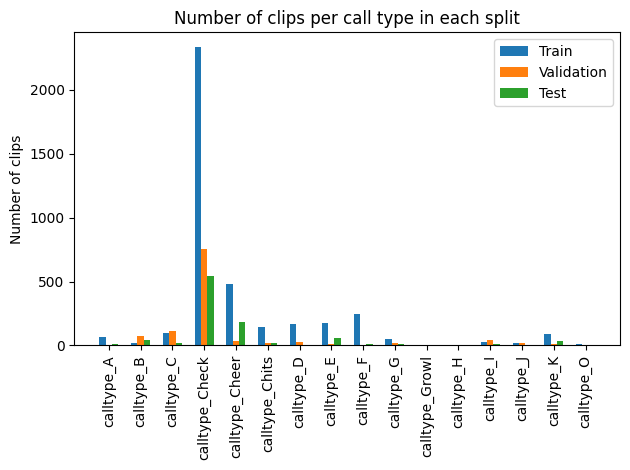

In [22]:
# bar plot number of calltype files in each split
import matplotlib.pyplot as plt
calltype_columns = [col for col in classes if col.startswith('calltype_')]
train_counts = train_set[calltype_columns].sum()
val_counts = val_set[calltype_columns].sum()
test_counts = test_set[calltype_columns].sum()
x = range(len(calltype_columns))
plt.bar(x, train_counts, width=0.2, label='Train')
plt.bar([i + 0.2 for i in x], val_counts, width=0.2, label='Validation')
plt.bar([i + 0.4 for i in x], test_counts, width=0.2, label='Test')
plt.xticks([i + 0.2 for i in x], calltype_columns, rotation=90)
plt.ylabel('Number of clips')
plt.title('Number of clips per call type in each split')
plt.legend()
plt.tight_layout()
plt.show()

### resample

In [ ]:
# resample train set by upsampling minority classes
seed = 42

def resample_set(df, n_samples_per_class, seed=42):
    """
    Resample a multi-label dataset to have n_samples_per_class for each class.
    For upsampling: duplicates rows as needed (keeps duplicates)
    For downsampling: randomly selects subset of samples
    """
    resampled_dfs = []
    
    # Get label columns (exclude metadata columns)
    label_cols = [col for col in df.columns if col not in ['file', 'start_time', 'end_time']]
    
    for class_label in label_cols:
        # Get rows that have this class
        class_df = df[df[class_label] == 1].copy()
        
        if len(class_df) == 0:
            print(f"Warning: No samples found for {class_label}")
            continue
        
        # Sample with or without replacement depending on class size
        if len(class_df) < n_samples_per_class:
            # Upsample with replacement - this creates duplicates
            sampled_df = class_df.sample(
                n=n_samples_per_class, replace=True, random_state=seed
            )
            print(f"Upsampled {class_label} from {len(class_df)} to {n_samples_per_class} clips.")
        else:
            # Downsample without replacement
            sampled_df = class_df.sample(
                n=n_samples_per_class, replace=False, random_state=seed
            )
            print(f"Downsampled {class_label} from {len(class_df)} to {n_samples_per_class} clips.")
        
        resampled_dfs.append(sampled_df)
    
    # Concatenate all resampled dataframes
    # Note: We keep duplicates! That's the whole point of upsampling
    # If a clip belongs to multiple classes, it may appear multiple times
    resampled_set = pd.concat(resampled_dfs, axis=0)
    resampled_set = resampled_set.reset_index(drop=True)
    
    print(f"\nTotal clips after resampling (with duplicates): {len(resampled_set)}")
    
    # Show per-class counts after resampling
    print("\nPer-class counts after resampling:")
    for col in label_cols:
        count = resampled_set[col].sum()
        print(f"  {col}: {count}")
    
    return resampled_set

resampled_train_set = resample_set(train_set, 100, seed)
resampled_train_set.set_index(['file', 'start_time', 'end_time'], inplace=True)
print("\nResampled training set created.")
resampled_val_set = resample_set(val_set, 20, seed)
resampled_val_set.set_index(['file', 'start_time', 'end_time'], inplace=True)
print("\nResampled validation set created.")
test_set.set_index(['file', 'start_time', 'end_time'], inplace=True)

Upsampled calltype_A from 63 to 100 clips.
Upsampled calltype_B from 17 to 100 clips.
Upsampled calltype_C from 97 to 100 clips.
Downsampled calltype_Check from 2333 to 100 clips.
Downsampled calltype_Cheer from 484 to 100 clips.
Downsampled calltype_Chits from 145 to 100 clips.
Downsampled calltype_D from 169 to 100 clips.
Downsampled calltype_E from 178 to 100 clips.
Downsampled calltype_F from 242 to 100 clips.
Upsampled calltype_G from 47 to 100 clips.
Upsampled calltype_Growl from 4 to 100 clips.
Upsampled calltype_H from 6 to 100 clips.
Upsampled calltype_I from 26 to 100 clips.
Upsampled calltype_J from 19 to 100 clips.
Upsampled calltype_K from 88 to 100 clips.
Upsampled calltype_O from 14 to 100 clips.

Total unique clips after resampling: 901

Per-class counts after resampling:
  calltype_A: 51
  calltype_B: 17
  calltype_C: 61
  calltype_Check: 100
  calltype_Cheer: 100
  calltype_Chits: 100
  calltype_D: 100
  calltype_E: 100
  calltype_F: 100
  calltype_G: 43
  calltype_Gr

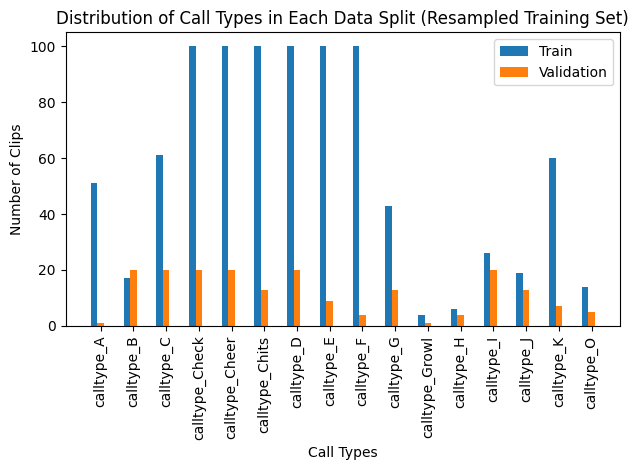

In [24]:
# bar plot number of calltype files in each split resampled
import matplotlib.pyplot as plt
calltype_columns = [col for col in clip_labels.columns if col.startswith('calltype_')]
train_counts = resampled_train_set[calltype_columns].sum()
val_counts = resampled_val_set[calltype_columns].sum()
#test_counts = test_set[calltype_columns].sum()
x = range(len(calltype_columns))
plt.bar(x, train_counts, width=0.2, label='Train')
plt.bar([i + 0.2 for i in x], val_counts, width=0.2, label='Validation')
# plt.bar([i + 0.4 for i in x], test_counts, width=0.2, label='Test')
plt.xticks([i + 0.2 for i in x], calltype_columns, rotation=90)
plt.xlabel('Call Types')
plt.ylabel('Number of Clips')
plt.title('Distribution of Call Types in Each Data Split (Resampled Training Set)')
plt.legend()
plt.tight_layout()
plt.show()

In [46]:
#resampled_train_set.to_csv("resampled_train_set.csv")
#val_set.to_csv("validation_set.csv")

In [47]:
# read in the training, validation and test set
import pandas as pd
import bioacoustics_model_zoo as bmz
import torch
import numpy as np

# Allow numpy types to be loaded
torch.serialization.add_safe_globals([np.float32, np.float64, np.int32, np.int64])

birdnet = bmz.BirdNET()
#train_set = pd.read_csv('resampled_train_set.csv', index_col=[0,1,2])
#val_set = pd.read_csv('validation_set.csv', index_col=[0,1,2])

downloading model from URL...


/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/opensoundscape/ml/cnn.py:599: UserWarning: 
                    This architecture is not listed in opensoundscape.ml.cnn_architectures.ARCH_DICT.
                    It will not be available for loading after saving the model with .save() (unless using pickle=True). 
                    To make it re-loadable, define a function that generates the architecture from arguments: (n_classes, n_channels) 
                    then use opensoundscape.ml.cnn_architectures.register_architecture() to register the generating function.

                    The function can also set the returned object's .constructor_name to the registered string key in ARCH_DICT
                    to avoid this warning and ensure it is reloaded correctly by opensoundscape.ml.load_model().

                    See opensoundscape.ml.cnn_architectures module for examples of constructor functions
                    
  warnings.warn(
/home/She

In [48]:
resampled_train_set

,,,calltype_A,calltype_B,calltype_C,calltype_Check,calltype_Cheer,calltype_Chits,calltype_D,calltype_E,calltype_F,calltype_G,calltype_Growl,calltype_H,calltype_I,calltype_J,calltype_K,calltype_L,calltype_M,calltype_N,calltype_O
file,start_time,end_time,,,,,,,,,,,,,,,,,,,
/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/Call_audios/padded_3s/SL12_Trial_2_trim_35.05393013_35.43714167_A.WAV,0.0,3.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/Call_audios/padded_3s/SL12_Trial_2_trim_44.76526132_45.03350941_A.WAV,0.0,3.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/Call_audios/padded_3s/SL12_Trial_2_trim_58.75293696_59.1361485_A.WAV,0.0,3.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/Call_audios/padded_3s/SL12_Trial_2_trim_47.38900826_47.70994793_A.WAV,0.0,3.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/Call_audios/padded_3s/SL12_Trial_2_trim_49.65953666_50.04274821_A.WAV,0.0,3.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/Call_audios/padded_3s/EF01_Trial_3_trim_11.75090701_12.06302049_O.WAV,0.0,3.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/Call_audios/padded_3s/EF01_Trial_3_trim_3.325259101_3.568693762_O.WAV,0.0,3.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/Call_audios/padded_3s/EF01_Trial_3_trim_18.14340829_18.46729963_O.WAV,0.0,3.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True


In [49]:
emb_train = birdnet.embed(resampled_train_set, return_dfs=False, batch_size=128, num_workers=0)
emb_val = birdnet.embed(resampled_val_set, return_dfs=False, batch_size=128, num_workers=0)

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
# We want to train the classifier on the 'A' class here, corresponding to the primary R. sierrae call type.
# Let's replace fc output layer with 1-output layer for class 'A'
classes = list(resampled_train_set.columns)
birdnet.change_classes(classes)

# Convert all label columns to float to avoid object type errors
resampled_train_set = resampled_train_set.astype(float)
resampled_val_set = resampled_val_set.astype(float)
# Convert labels to float (in case they're boolean or object type)
train_labels = resampled_train_set.astype(float).values
val_labels = resampled_val_set.astype(float).values

# fit the classification head with embeddings and labels
# birdnet.network.fit(emb_train, train_labels, emb_val, val_labels)

In [51]:
birdnet = bmz.BirdNET()

downloading model from URL...


/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/opensoundscape/ml/cnn.py:599: UserWarning: 
                    This architecture is not listed in opensoundscape.ml.cnn_architectures.ARCH_DICT.
                    It will not be available for loading after saving the model with .save() (unless using pickle=True). 
                    To make it re-loadable, define a function that generates the architecture from arguments: (n_classes, n_channels) 
                    then use opensoundscape.ml.cnn_architectures.register_architecture() to register the generating function.

                    The function can also set the returned object's .constructor_name to the registered string key in ARCH_DICT
                    to avoid this warning and ensure it is reloaded correctly by opensoundscape.ml.load_model().

                    See opensoundscape.ml.cnn_architectures module for examples of constructor functions
                    
  warnings.warn(
/home/She

In [ ]:
# num_workers=0
# birdnet.initialize_custom_classifier(classes=classes)

# num_workers=0
birdnet.change_classes(classes)




In [55]:
birdnet.train(
    train_df=resampled_train_set,
    validation_df=resampled_val_set,
    embedding_batch_size=128,
    embedding_num_workers=4,
    n_augmentation_variants=2,
    steps=250,
)

Embedding the training samples 2 times with stochastic augmentation


  0%|          | 0/2 [00:00<?, ?it/s]

/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=553860) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


Embedding the validation samples


  0%|          | 0/2 [00:00<?, ?it/s]

Fitting the classifier
Epoch 100/250, Loss: 0.12077789753675461, Val Loss: 0.18076664209365845
val AU ROC: nan
val MAP: 0.382


/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/opensoundscape/ml/shallow_classifier.py:110: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_features = torch.tensor(train_features, dtype=torch.float32, device=device)
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/opensoundscape/ml/shallow_classifier.py:111: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_labels = torch.tensor(train_labels, dtype=torch.float32, device=device)
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/opensoundscape/ml/shallow_classifier.py:115: UserWarning: To copy construct from a tensor, it is recommended to use sourceTens

Epoch 200/250, Loss: 0.09634868055582047, Val Loss: 0.1675247699022293
val AU ROC: nan
val MAP: 0.444
Training complete


/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


In [ ]:
preds = birdnet.network(torch.tensor(emb_val)).detach()
print(preds.shape)

torch.Size([210, 19])


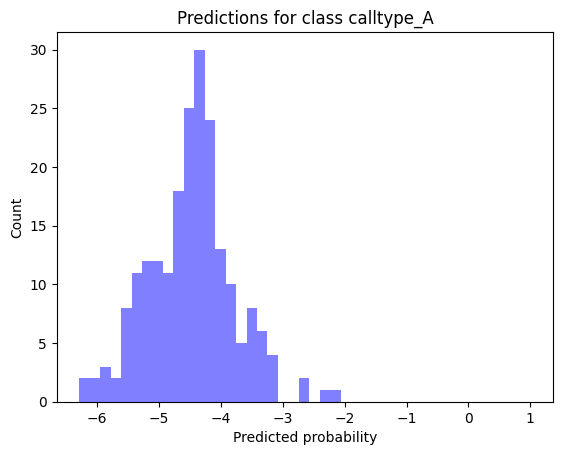

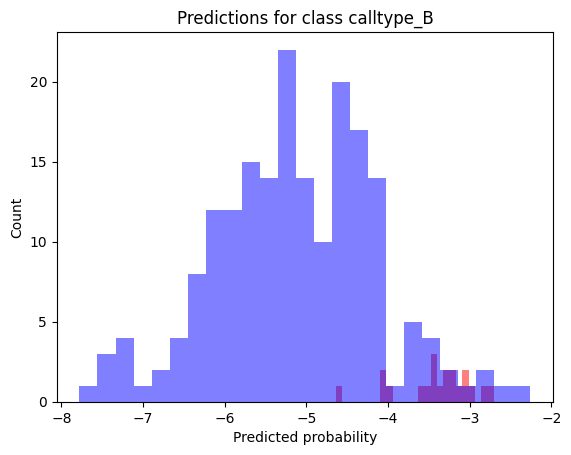

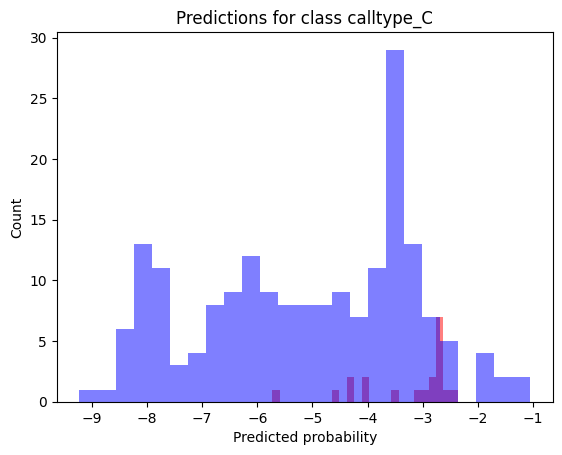

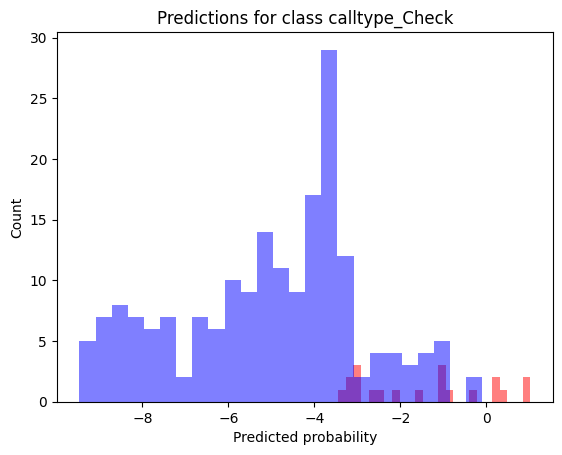

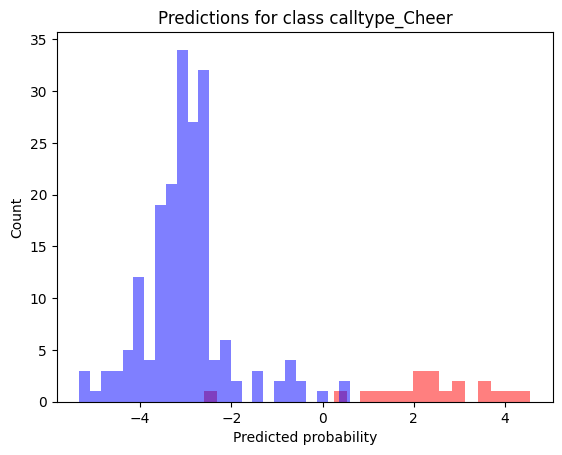

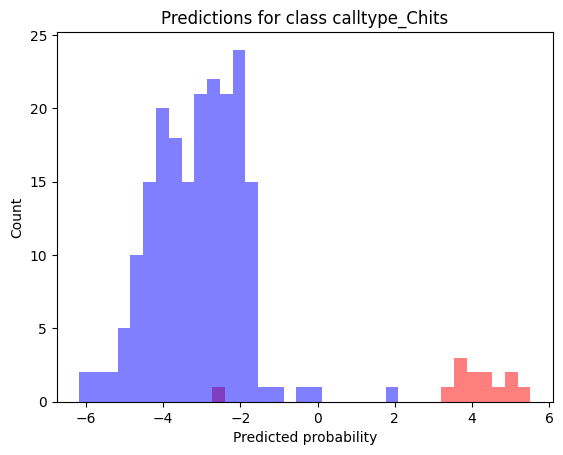

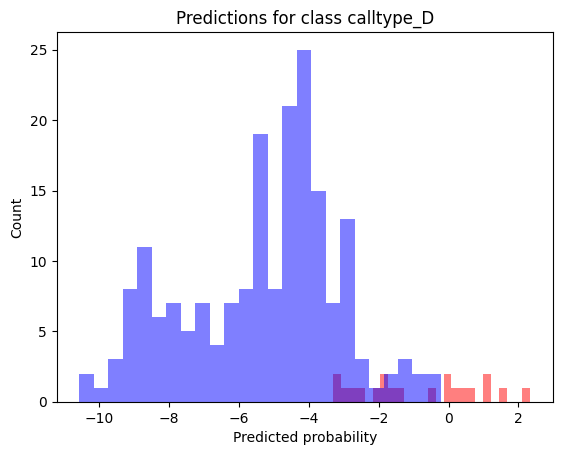

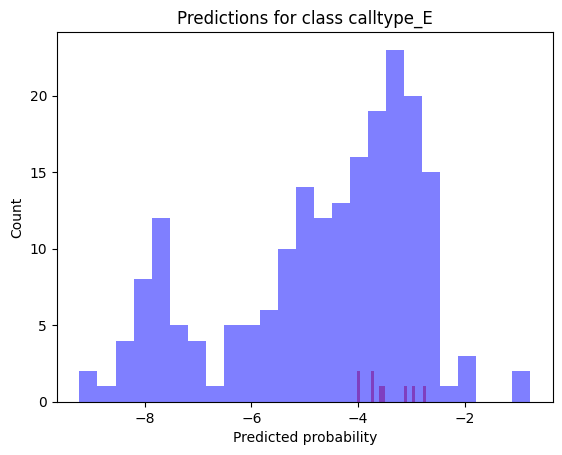

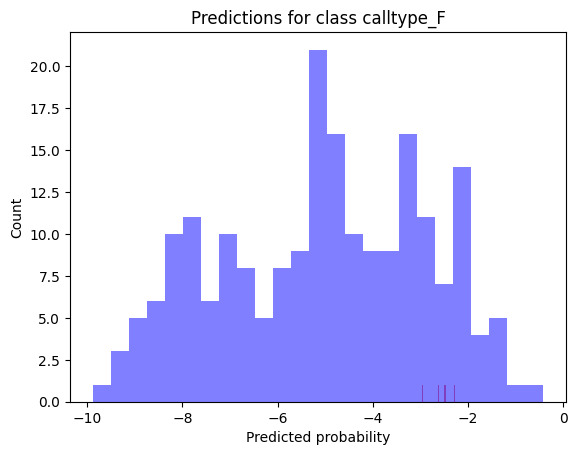

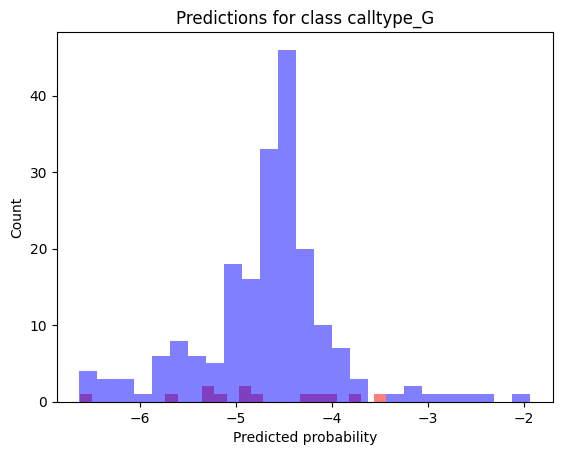

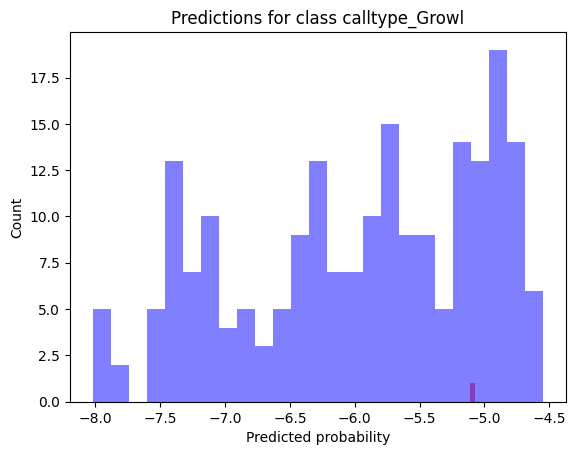

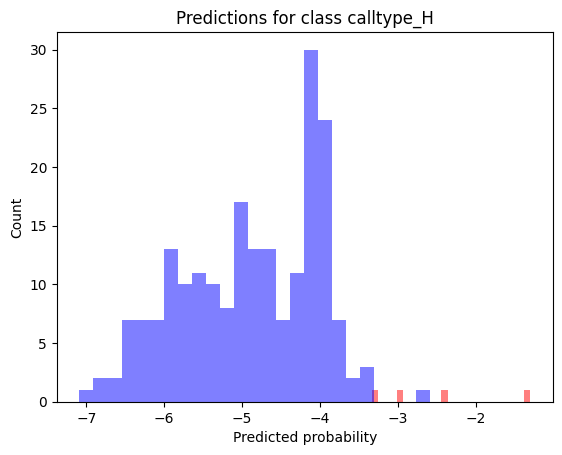

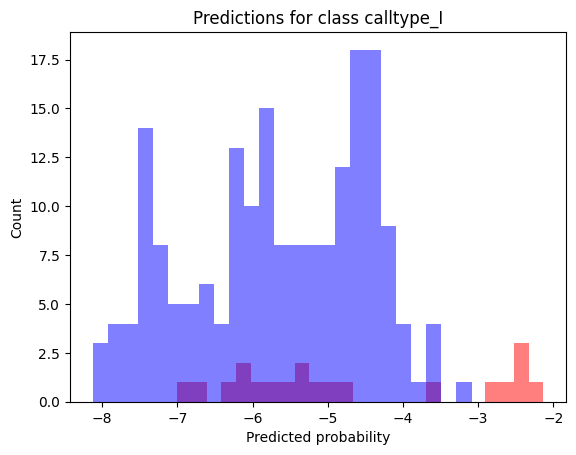

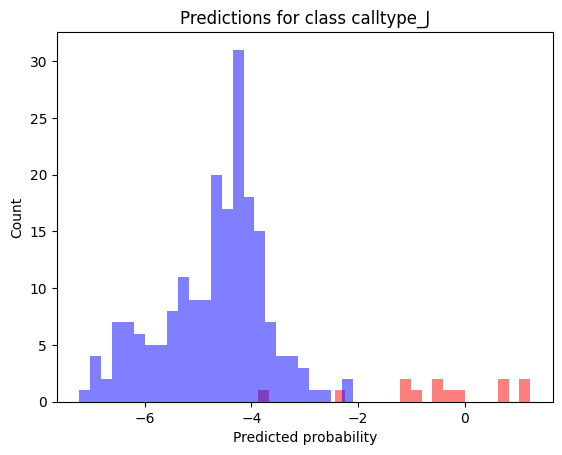

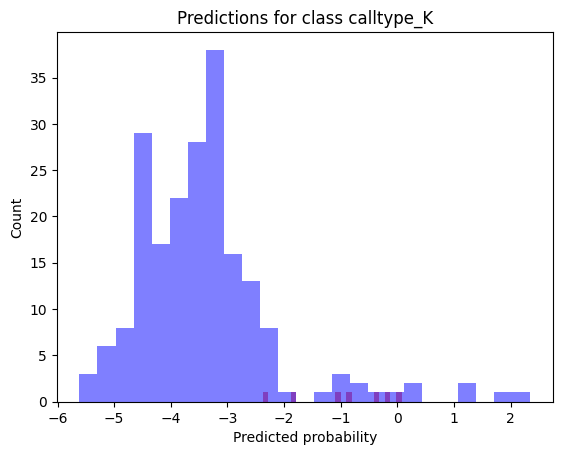

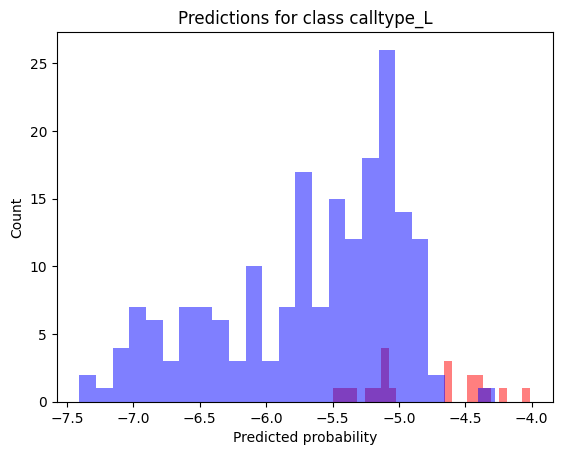

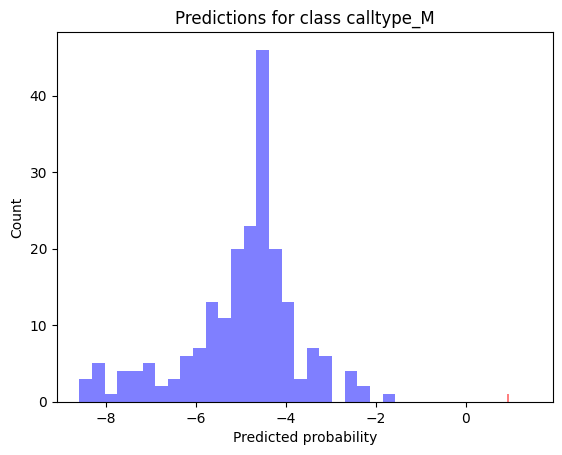

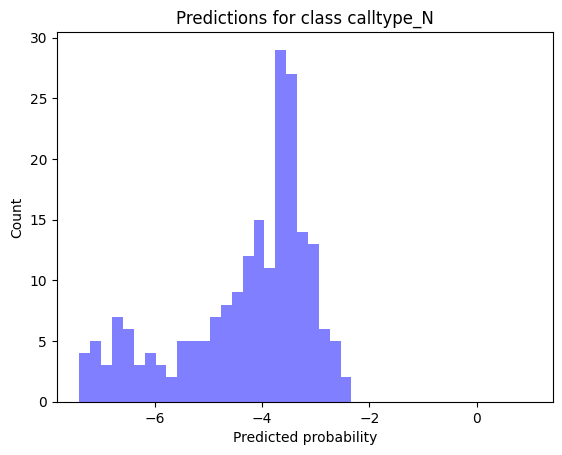

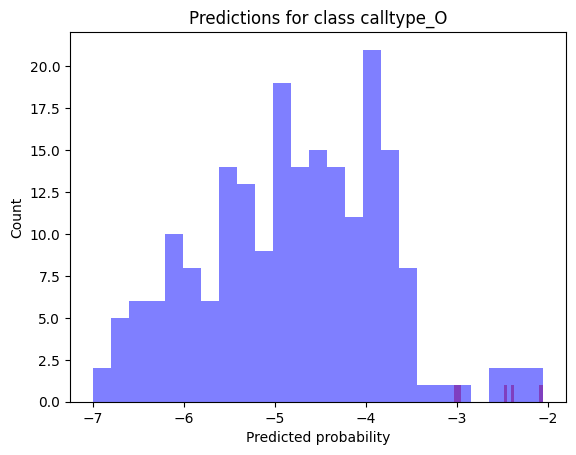

In [57]:
# make predictions by passing the embeddings through the classifier
preds = birdnet.network(torch.tensor(emb_val)).detach()

# plot the histograms for the 3 biggest classes

# plot histograms of predictions for the biggest classes
import matplotlib.pyplot as plt
for class_name in classes:
    class_idx = list(resampled_val_set.columns).index(class_name)
    plt.figure()
    positives = resampled_val_set.values[:, class_idx] == 1
    negatives = resampled_val_set.values[:, class_idx] == 0
    plt.hist(preds[positives, class_idx].numpy(), bins=25, color="red", alpha=0.5, label='Positive samples')
    plt.hist(preds[negatives, class_idx].numpy(), bins=25, color ="blue", alpha=0.5, label='Negative samples')
    plt.title(f"Predictions for class {class_name}")
    plt.xlabel("Predicted probability")
    plt.ylabel("Count")
    plt.show()

In [59]:
#can you write code for a classification report for each class?
from sklearn.metrics import classification_report
threshold = 0.5
pred_labels = (preds.numpy() >= threshold).astype(int)
report = classification_report(resampled_val_set.values, pred_labels, target_names=classes)
print(report)

                precision    recall  f1-score   support

    calltype_A       0.00      0.00      0.00         0
    calltype_B       0.00      0.00      0.00        20
    calltype_C       0.00      0.00      0.00        20
calltype_Check       1.00      0.10      0.18        20
calltype_Cheer       0.95      0.90      0.92        20
calltype_Chits       0.92      0.92      0.92        13
    calltype_D       1.00      0.25      0.40        20
    calltype_E       0.00      0.00      0.00         9
    calltype_F       0.00      0.00      0.00         4
    calltype_G       0.00      0.00      0.00        13
calltype_Growl       0.00      0.00      0.00         1
    calltype_H       0.00      0.00      0.00         4
    calltype_I       0.00      0.00      0.00        20
    calltype_J       1.00      0.31      0.47        13
    calltype_K       0.00      0.00      0.00         7
    calltype_L       0.00      0.00      0.00        20
    calltype_M       1.00      1.00      1.00  

/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/Shelby/miniconda3/envs/BlackbirdOP_py312/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn

In [60]:
emb_test = birdnet.embed(test_set, return_dfs=False, batch_size=128, num_workers=0)
preds = birdnet.network(torch.tensor(emb_test)).detach()

# plot histograms of predictions for the biggest classes
import matplotlib.pyplot as plt
for class_name in classes:
    class_idx = list(test_set.columns).index(class_name)
    plt.figure()
    positives = test_set.values[:, class_idx] == 1
    negatives = test_set.values[:, class_idx] == 0
    plt.hist(preds[positives, class_idx].numpy(), bins=25, color="red", alpha=0.5, label='Positive samples')
    plt.hist(preds[negatives, class_idx].numpy(), bins=25, color ="blue", alpha=0.5, label='Negative samples')
    plt.title(f"Predictions for class {class_name}")
    plt.xlabel("Predicted probability")
    plt.ylabel("Count")
    plt.show()

  0%|          | 0/8 [00:00<?, ?it/s]

RuntimeError: Expected all tensors to be on the same device, but got mat1 is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA_addmm)

In [ ]:
# classification report on test set
from sklearn.metrics import classification_report
threshold = 0.5
pred_labels = (preds.numpy() >= threshold).astype(int)
report = classification_report(test_set.values, pred_labels, target_names=classes)
print(report)

Save the model

In [54]:
birdnet.save("/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/blackbirdcallv1.model")

Code for loading the model later

In [ ]:
# reload the saved model later, perhaps in a different script or notebook:
loaded_model = bmz.BirdNET.load("./saved_custom_birdnet.model")

# use the model to make predictions on a dataframe or on a list of audio files
preds = loaded_model.predict(labels_val.head())